In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

if os.name == 'posix':
    print("This is a UNIX system.")
    UNIX = True
elif os.name == 'nt':
    print("This is a Windows system.")
    UNIX = False
else:
    print("Unknown operating system.")
    UNIX = False

This is a Windows system.


In [2]:
if UNIX:
    base = '/run/user/1000/gvfs/smb-share:server=itet-stor.ee.ethz.ch,share=bmaure/'
else:
    base = 'Y:/'
data_dir = f'{base}neuronies/plasticity/00_inkube/12_cpp_testing/'
def get_ch(nw=0, el=0):
    return np.where(np.logical_and(mapping_matrix[:,0] == nw, mapping_matrix[:,1] == el))[0]
def get_nw_el(ch):
    return mapping_matrix[ch]

In [3]:

# **Load HDF5 File**
file = "250327_spike_data_095412_spontaneous.h5"  # Change if needed
filename = os.path.join(data_dir, file)
print(f"📂 Loading file: {filename}")

with h5py.File(filename, "r") as f:
    # **Print metadata**
    print("📌 Metadata:")
    for key, value in f["metadata"].attrs.items():
        print(f"  {key}: {value}")
    fs = f["metadata"].attrs["fs"]

    # **Print dataset info**
    print("\n📂 Datasets:")
    for group in f.keys():
        print(f"  📁 {group}")
        for key in f[group].keys():
            print(f"    📄 {key}: shape={f[group][key].shape}, dtype={f[group][key].dtype}")

    # **Load spike data**
    spike_channels = f["spike_data/spike_channels"][:]
    spike_times = f["spike_data/spike_times"][:]
    spike_waveforms = f["spike_data/spike_waveforms"][:]

    # **Load stimulation data (if exists)**
    if "stimulation_data" in f:
        stim_times = f["stimulation_data/stim_times"][:]
        stim_triggers = f["stimulation_data/stim_triggers"][:]
        stim_amplitudes = f["stimulation_data/stim_amplitudes"][:]
        stim_matrix = f["stimulation_data/stim_matrix"][:]
    else:
        stim_times = stim_triggers = stim_amplitudes = stim_matrix = None

    if "env_data" in f:
        try: 
            env_times = f["env_data/env_times"][:]
            env_mea_data = f["env_data/env_mea_data"][:]
            env_reservoir_data = f["env_data/env_reservoir_data"][:]
        except Exception as e:
            pass

    # **Load Electrode Mapping Matrix**
    if "electrode_mapping/spike_ch_to_network_electrode_mapping_matrix" in f:
        mapping_matrix = f["electrode_mapping/spike_ch_to_network_electrode_mapping_matrix"][:]
        print("\n📌 Mapping Matrix Shape:", mapping_matrix.shape)

    if "stimulation_parameters" in f:
        stim_params = f["stimulation_parameters"].attrs
        print("\n📌 Stimulation Parameters:")
        for key, value in stim_params.items():
            print(f" {key}: {value}")

# **Print First 10 Spike Events**
print("\n📊 First 10 spike events:")
print("Times:", spike_times[:10])
print("Channels:", spike_channels[:10])

# **Check if stimulation data exists**
if stim_times is not None:
    print("\n📊 First 10 stim events:")
    print("Stim Times:", stim_times[:10])
    print("Stim Triggers:", stim_triggers[:10])
    print("Stim Amplitudes:", stim_amplitudes[:10])
    print("Stim Matrix (first 10 rows):")
    print(stim_matrix[:10, :])


📂 Loading file: Y:/neuronies/plasticity/00_inkube/12_cpp_testing/250327_spike_data_095412_spontaneous.h5
📌 Metadata:
  creation_time: 2025-03-27 09:54:12.815
  description: Spike data file for testing
  fs: 17361
  threshold: 0
  time_started_pkg_0: 2025-03-27 09:54:12.809

📂 Datasets:
  📁 electrode_mapping
    📄 spike_ch_to_network_electrode_mapping_matrix: shape=(240, 2), dtype=int64
  📁 env_data
    📄 env_last_pkg: shape=(53,), dtype=uint64
    📄 env_mea_data: shape=(53, 4), dtype=float32
    📄 env_reservoir_data: shape=(53, 3), dtype=float32
    📄 env_times: shape=(53,), dtype=float64
  📁 metadata
  📁 spike_data
    📄 spike_channels: shape=(213600,), dtype=uint8
    📄 spike_times: shape=(213600,), dtype=uint64
    📄 spike_waveforms: shape=(213600, 45), dtype=float32
  📁 stimulation_data
    📄 stim_amplitudes: shape=(0,), dtype=uint8
    📄 stim_matrix: shape=(0, 2), dtype=uint8
    📄 stim_times: shape=(0,), dtype=uint64
    📄 stim_triggers: shape=(0,), dtype=uint64
  📁 stimulation_p

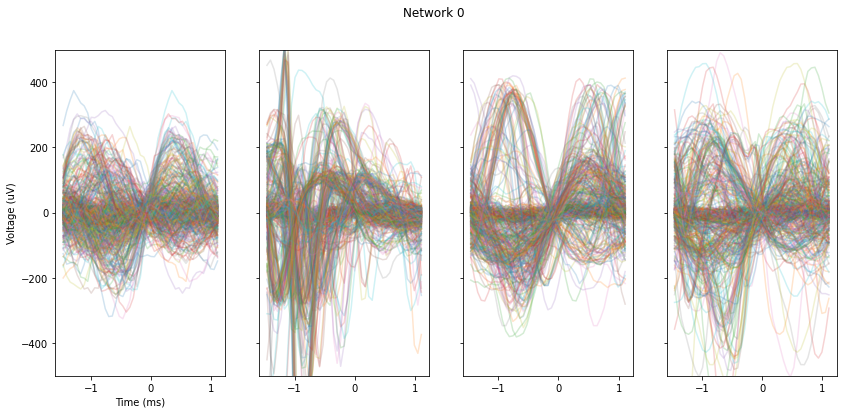

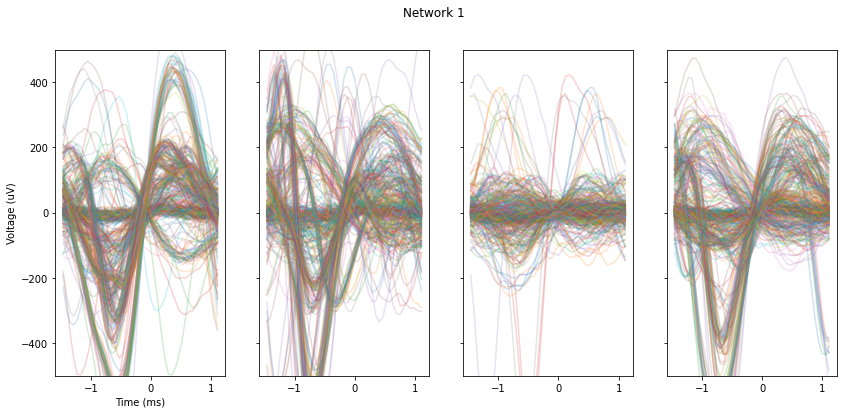

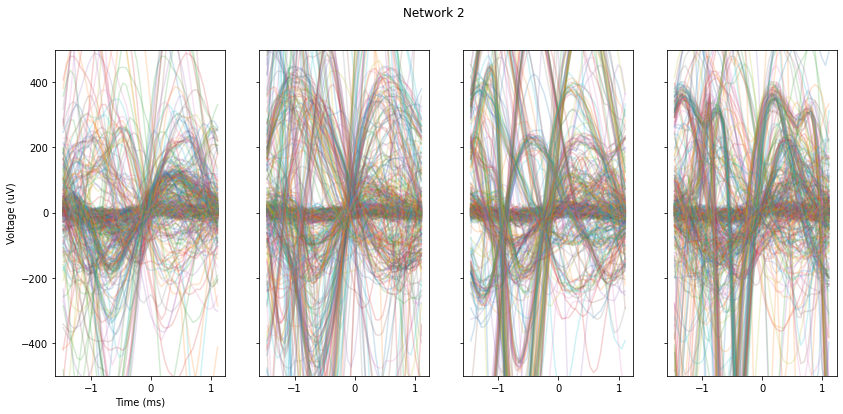

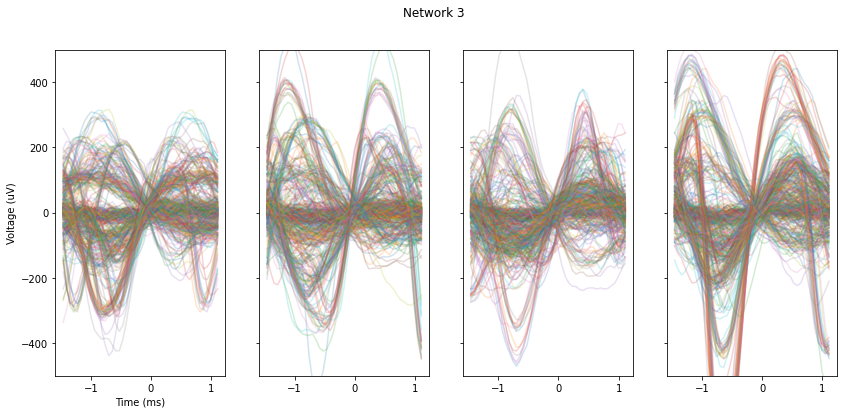

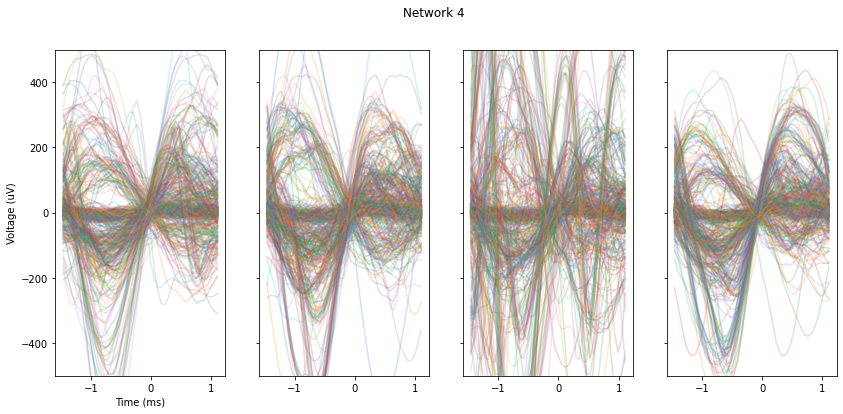

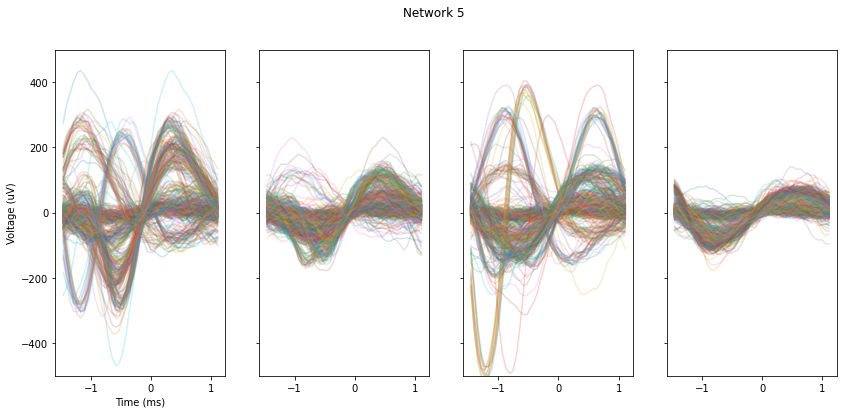

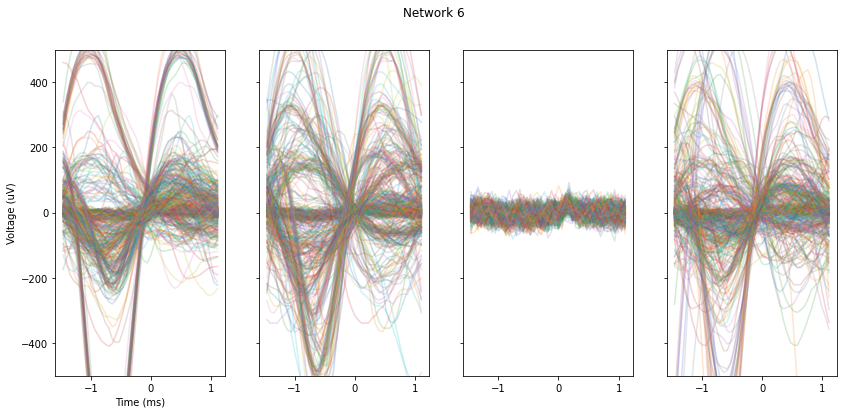

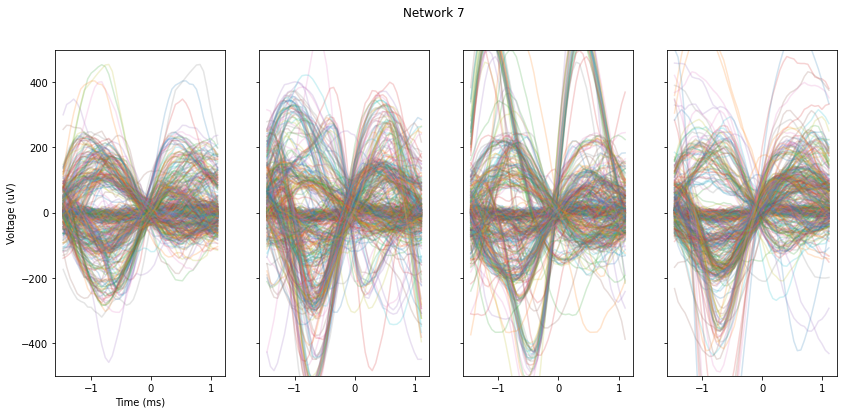

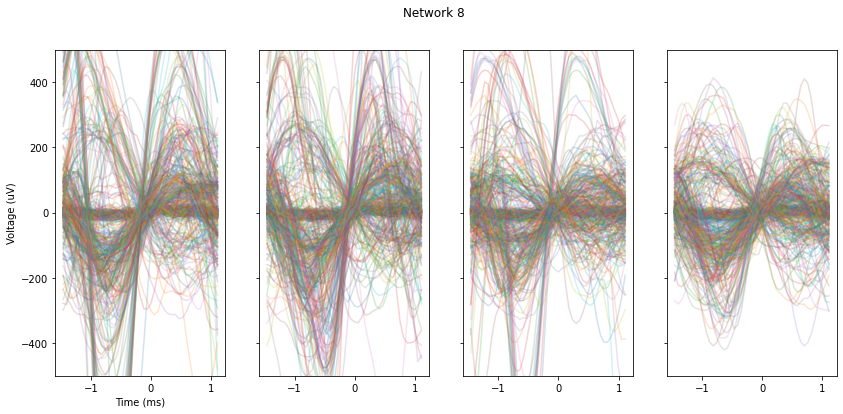

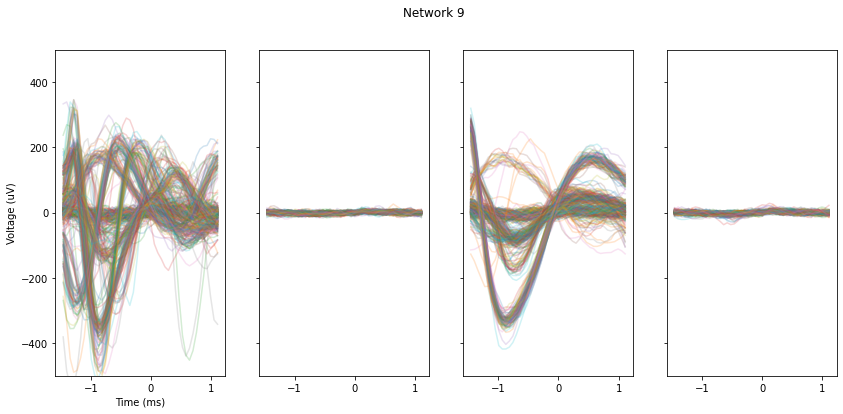

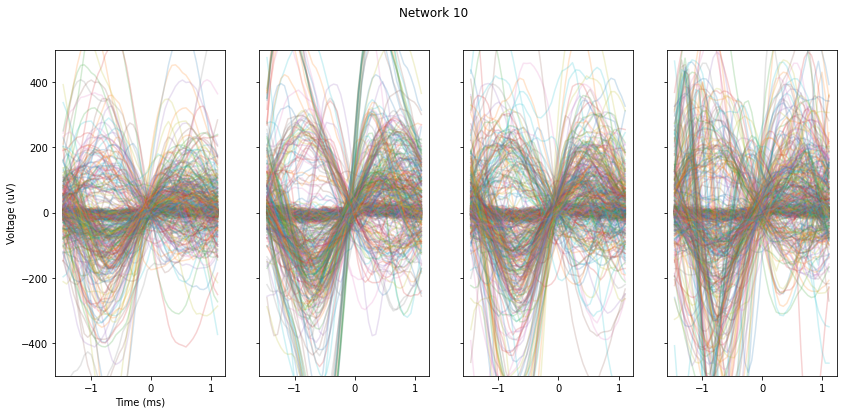

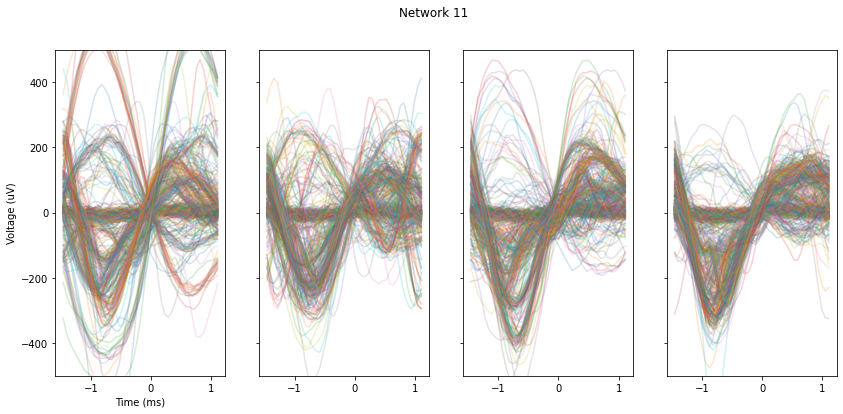

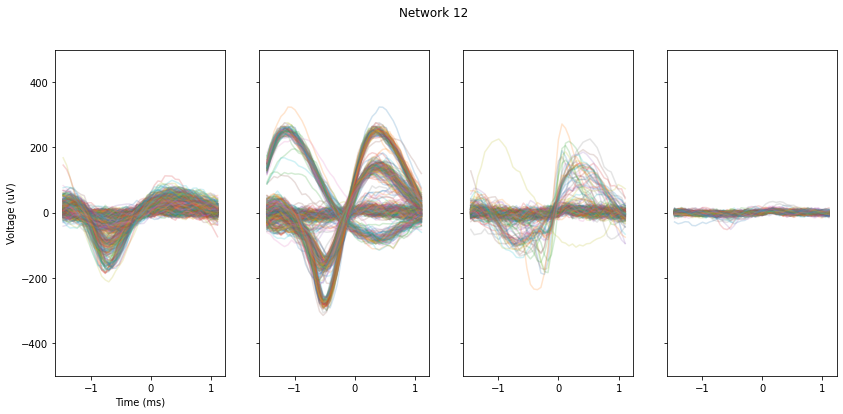

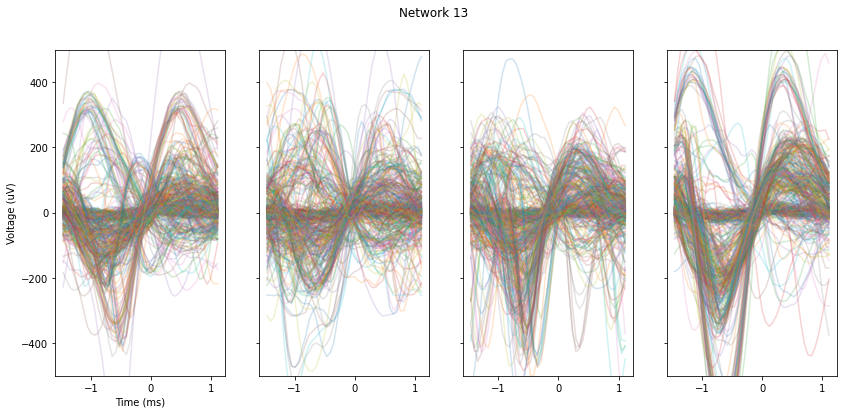

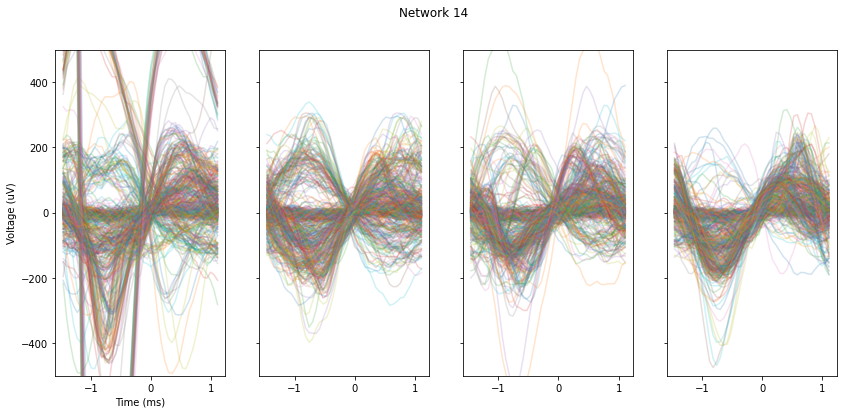

In [4]:
t = (np.arange(spike_waveforms[0].shape[0])+20-spike_waveforms[0].shape[0])/17.13
max_num_waves = 512
for nw in range(15):
    nw_ch = np.where(mapping_matrix[:,0] == nw)[0]
    fig, axs = plt.subplots(1, 4, figsize=(14, 6), sharex=True, sharey=True)
    for axs_id, ch in enumerate(nw_ch):
        ch_ids = np.where(spike_channels == ch)[0]
        if len(ch_ids) > max_num_waves:
            ch_ids = ch_ids[:max_num_waves]
        axs[axs_id].plot(np.tile(t, ((len(ch_ids), 1))).T, (spike_waveforms[ch_ids]*0.195).T, alpha=.2)
    axs[0].set_ylabel('Voltage (uV)')
    axs[0].set_xlabel('Time (ms)')
    axs[0].set_ylim([-500, 500])
    fig.suptitle(f'Network {nw}')


In [7]:
s, s_count = np.unique(stim_triggers, return_counts=True)

In [8]:
selected_stim = s[s_count < 60]

In [9]:
ids = np.where(np.isin(stim_triggers, selected_stim))[0]

In [10]:
stim_times = stim_times[ids]
stim_triggers = stim_triggers[ids]
stim_amplitudes = stim_amplitudes[ids]
stim_matrix = stim_matrix[ids]

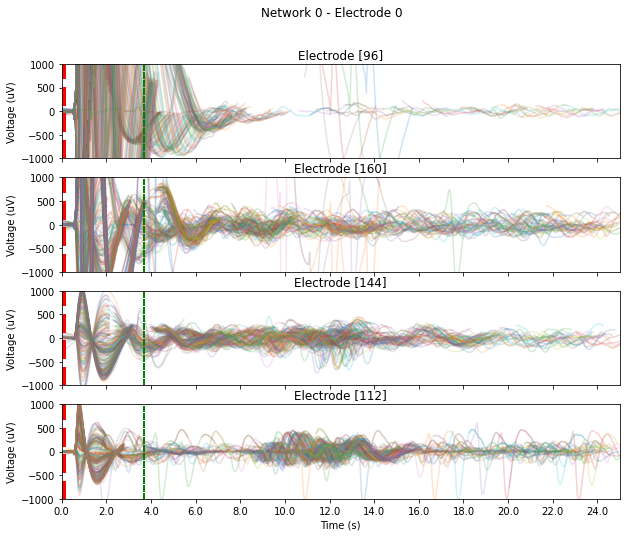

In [12]:
# **Parameters**
time_delay = 25e-3  # s
num_samples = int(time_delay * fs)  # Convert to number of samples
t = (np.arange(spike_waveforms[0].shape[0])+20-spike_waveforms[0].shape[0])

# **Unique stimulations**
unique_stims = np.unique(stim_matrix, axis=0)

# **Plot responses per network**
for nw, el in unique_stims:
    if nw > 14:
        continue
    ch_stim = get_ch(nw, el)
    if len(ch_stim) == 0:
        continue
    selected_stims = np.where(np.logical_and(stim_matrix[:,0] == nw, stim_matrix[:,1] == el))[0]
    
    fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True, sharey=True)
    fig.suptitle(f"Network {nw} - Electrode {el}")
    
    # Find all spikes in network within 30ms of each stimulation
    for stim_id, stim_time in enumerate(stim_times[selected_stims]):
        relevant_spikes = np.where((spike_times >= (stim_time - 20)) & (spike_times < stim_time + num_samples))[0]
        relevant_channels = spike_channels[relevant_spikes]
        relevant_waveforms = spike_waveforms[relevant_spikes]
        relevant_times = spike_times[relevant_spikes]
        
        # Iterate over the 4 network electrodes
        nw_ch = [get_ch(nw, e) for e in range(4)]
        for i, ch in enumerate(nw_ch): 
            ch_indices = np.where(relevant_channels == ch)[0]
            if len(ch_indices) > 0:
                t_vec = relevant_times[ch_indices] - stim_time
                
                t_mat = t_vec[:,np.newaxis] * np.ones((1, relevant_waveforms.shape[1])) + t

                axs[i].plot(t_mat.T, relevant_waveforms[ch_indices].T * 0.195, alpha=0.2)
                axs[i].set_title(f"Electrode {ch}")
                axs[i].set_ylabel("Voltage (uV)")
        
        for i in range(4):
            axs[i].axvline(x=stim_triggers[selected_stims[stim_id]]-stim_time, color='g', linestyle='--')
            axs[i].axvline(x=1, color='r', linestyle='--', linewidth=5)

    axs[-1].set_xlim([0, num_samples])
    axs[-1].set_xticks(np.arange(0, num_samples, fs/1e3*2))
    axs[-1].set_xticklabels(np.arange(0, time_delay*1e3, 2))
    axs[-1].set_xlabel("Time (s)")
    axs[-1].set_ylabel("Voltage (uV)")
    axs[-1].set_ylim([-1000, 1000])
    plt.show()

In [ ]:
nw_ch = get_ch(5,1)

array([51], dtype=int64)

c:\Users\bmaurer\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\stats\_distn_infrastructure.py:2071: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


Optimal number of clusters: 3


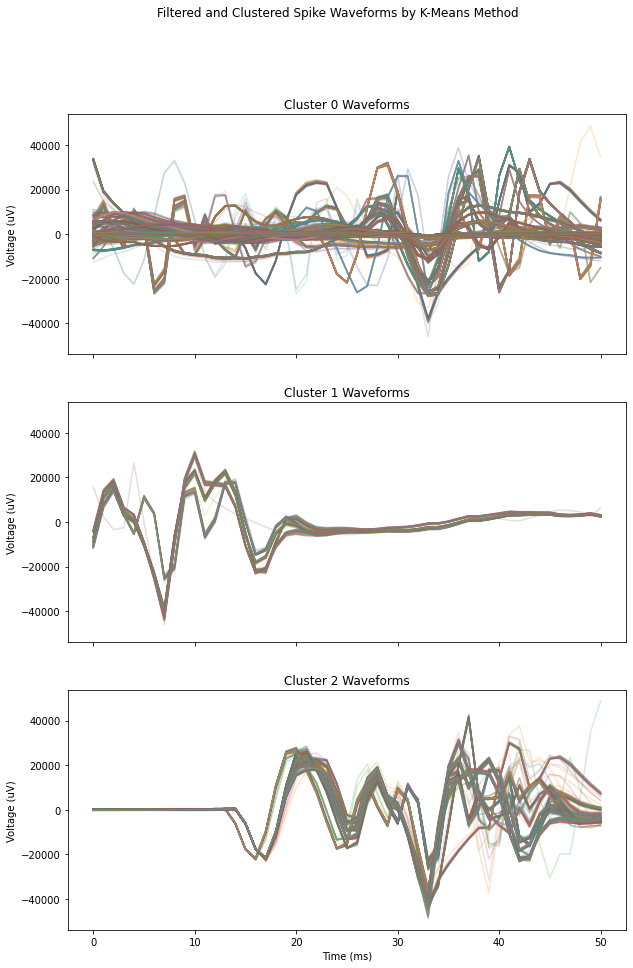

Final number of clusters after merging: 3


In [14]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import numpy as np
import pywt
from scipy.stats import kstest, norm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial.distance import cosine

# **Parameters**
min_cluster_size = 20  # Minimum number of spikes per cluster to be considered real
noise_threshold = 5     # Remove electrodes with fewer than this number of spikes

# **Spike Sorting and Filtering**
valid_electrodes = []  # Electrodes that pass filtering
cluster_results = {}   # Store clustering results per electrode

for electrode in nw_ch: # np.unique(spike_channels):
    # Extract waveforms for this electrode
    ch_ids = np.where(spike_channels == electrode)[0]
    waveforms = spike_waveforms[ch_ids]


    # **Step 1: Extract waveforms (assuming spike_waveforms is available)**
    num_spikes, num_samples = waveforms.shape

    # **Step 2: Perform a 6-level Haar wavelet decomposition**
    wavelet = 'haar'
    wavelet_coeffs = [pywt.wavedec(waveforms[i, :], wavelet, level=4) for i in range(num_spikes)]

    # Convert wavelet coefficients to a structured array
    coeff_array = np.array([np.concatenate(coeffs) for coeffs in wavelet_coeffs])  # Shape: (num_spikes, num_coeffs)

    # **Step 3: Select the 15 most non-Gaussian wavelet coefficients**
    def lilliefors_test(data):
        """ Perform Lilliefors modification of KS test for normality. """
        mean, std = np.mean(data), np.std(data)
        return kstest(data, lambda x: norm.cdf(x, loc=mean, scale=std)).pvalue

    # Compute p-values for all wavelet coefficients
    p_values = np.array([lilliefors_test(coeff_array[:, i]) for i in range(coeff_array.shape[1])])

    # Select 15 coefficients with the smallest p-values (most deviating from normality)
    selected_features = coeff_array[:, np.argsort(p_values)[:15]]

    # **Step 4: Perform PCA with 4 components**
    pca = PCA(n_components=4)
    pca_features = pca.fit_transform(selected_features)

    # **Determine optimal K using Cohesion-Dispersion Index**
    k_values = range(2, 6)  # Maximum k is 5
    best_k = 2
    best_score = -np.inf

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(pca_features)
        score = silhouette_score(pca_features, labels) - davies_bouldin_score(pca_features, labels)
        if score > best_score:
            best_score = score
            best_k = k

    print(f"Optimal number of clusters: {best_k}")

    # **Final K-Means Clustering**
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_features)

    # **Remove noise: discard outliers beyond 95th percentile of cluster distances**
    distances = np.linalg.norm(pca_features - kmeans.cluster_centers_[labels], axis=1)
    threshold = np.percentile(distances, 95)
    valid_indices = np.where(distances <= threshold)[0]
    labels = labels[valid_indices]
    pca_features = pca_features[valid_indices]
    waveforms = waveforms[valid_indices]

    # **Merge indistinguishable clusters**
    cluster_means = [np.mean(waveforms[labels == i], axis=0) for i in range(best_k)]
    to_merge = []
    for i in range(best_k):
        for j in range(i + 1, best_k):
            fisher_distance = np.linalg.norm(pca_features[labels == i].mean(axis=0) - pca_features[labels == j].mean(axis=0))
            cosine_sim = 1 - cosine(cluster_means[i], cluster_means[j])
            if fisher_distance < 8 and cosine_sim > 0.9:
                to_merge.append((i, j))

    # Merge clusters
    for i, j in to_merge:
        labels[labels == j] = i

    # **Plot Clustered Waveforms**
    unique_clusters = np.unique(labels)
    fig, axs = plt.subplots(len(unique_clusters), 1, figsize=(10, 5 * len(unique_clusters)), sharex=True, sharey=True)
    if len(unique_clusters) == 1:
        axs = [axs]

    for ax, cluster_id in zip(axs, unique_clusters):
        cluster_indices = np.where(labels == cluster_id)[0]
        ax.plot(np.arange(num_samples), waveforms[cluster_indices].T, alpha=0.2)
        ax.set_title(f"Cluster {cluster_id} Waveforms")
        ax.set_ylabel("Voltage (uV)")

    axs[-1].set_xlabel("Time (ms)")
    plt.suptitle("Filtered and Clustered Spike Waveforms by K-Means Method")
    plt.show()

    # **Final Output: Labels and Processed Features**
    print(f"Final number of clusters after merging: {len(np.unique(labels))}")


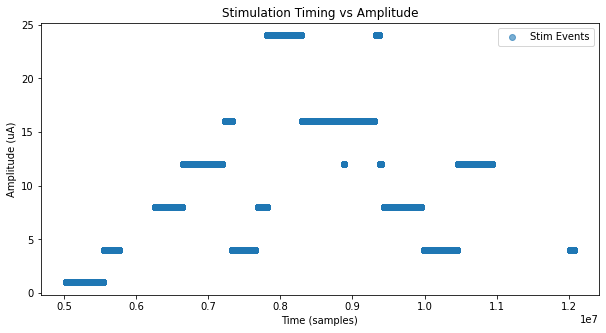

In [ ]:
if stim_times is not None:
    plt.figure(figsize=(10, 5))
    plt.scatter(stim_times, stim_amplitudes, alpha=0.6, label="Stim Events")

    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude (uA)")
    plt.title("Stimulation Timing vs Amplitude")
    plt.legend()
    plt.show()
else:
    print("⚠️ No stimulation data found in HDF5 file.")


In [ ]:

# **Define parameters**
time_delay = 25e-3  # 25 ms
num_samples = int(time_delay * fs)  # Convert to number of samples

# **Compute pattern times**
pattern_times = stim_times - stim_triggers

# group stimuli by trigger
same_trigger = np.where(np.diff(stim_triggers) == 0)[0] # what dim is this?

for nw in np.unique(stim_matrix[:,0]):
    nw_stim = np.where(stim_matrix[:,0] == nw)[0]
    nw_stim_triggers = stim_triggers[nw_stim]
    nw_pattern_times = pattern_times[nw_stim]
    nw_pattern       = np.zeros((np.unique(nw_stim_triggers).shape[0], 4))
    nw_spikes        = np.zeros((np.unique(nw_stim_triggers).shape[0], 4, num_samples))

    el_ids = np.where(mapping_matrix[:,0] == nw)[0]
    relevant_nw_spikes = np.where(spike_channels == el_ids)[0] # does this work multidim?
    for i, trigger in enumerate(np.unique(nw_stim_triggers)):
        trigger_ids = np.where(nw_stim_triggers == trigger)[0]
        nw_pattern[i,stim_matrix[trigger_ids,1]] = nw_pattern_times[trigger_ids]






# **Map electrodes to networks**
electrode_to_network = {mapping_matrix[i, 1]: mapping_matrix[i, 0] for i in range(mapping_matrix.shape[0])}
stim_networks = stim_matrix[:, 0]
stim_electrodes = stim_matrix[:, 1]

# **Create a lookup table for spike times within the time window**
spike_window_mask = (spike_times[:, None] >= stim_times) & (spike_times[:, None] < (stim_times + num_samples))
spike_window_indices = np.where(spike_window_mask)

# **Extract valid spike times and corresponding electrodes**
valid_spike_times = spike_times[spike_window_indices[0]] - stim_times[spike_window_indices[1]]
valid_spike_channels = spike_channels[spike_window_indices[0]]
valid_stim_indices = spike_window_indices[1]

# **Filter only spikes corresponding to the stimulation network**
valid_networks = np.vectorize(electrode_to_network.get)(valid_spike_channels)
stim_networks_expanded = stim_networks[valid_stim_indices]
network_mask = valid_networks == stim_networks_expanded

valid_spike_times = valid_spike_times[network_mask]
valid_spike_channels = valid_spike_channels[network_mask]
valid_stim_indices = valid_stim_indices[network_mask]
valid_networks = valid_networks[network_mask]

# **Create binary spike matrix using numpy indexing**
num_networks = len(np.unique(stim_networks))
num_patterns = len(np.unique(pattern_times))
num_repetitions = len(stim_times)
num_electrodes = len(np.unique(spike_channels))

binary_matrix = np.zeros((num_networks, num_patterns, num_repetitions, num_electrodes, num_samples), dtype=int)

# Convert to index mappings
network_indices = np.searchsorted(np.unique(stim_networks), valid_networks)
pattern_indices = np.searchsorted(np.unique(pattern_times), pattern_times[valid_stim_indices])
electrode_indices = np.searchsorted(np.unique(spike_channels), valid_spike_channels)

# Populate binary matrix efficiently
binary_matrix[network_indices, pattern_indices, valid_stim_indices, electrode_indices, valid_spike_times] = 1

# **Final Outputs**
print("Binary spike response matrix shape:", binary_matrix.shape)
print("Pattern times vector shape:", pattern_times.shape)
